In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("Student_Performance.csv")

# Remove empty unnamed columns
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# Features and target
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 4.082628398521854
R2 Score: 0.9889832909573145


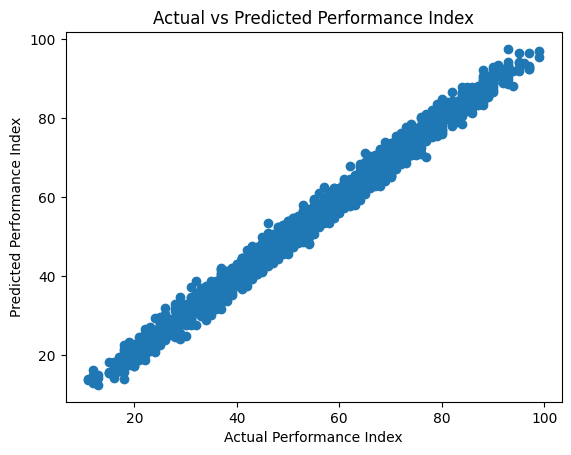

In [2]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")
plt.show()


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = pd.read_csv("Behavior_Recognition.csv")

# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop("Activity", axis=1)
y = df["Activity"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.981645139360979
Confusion Matrix:
 [[280   0   0   0   0   0]
 [  0 253   9   0   0   0]
 [  0  11 265   0   0   0]
 [  0   0   0 245   0   2]
 [  0   0   0   1 205   0]
 [  0   0   0   2   2 196]]


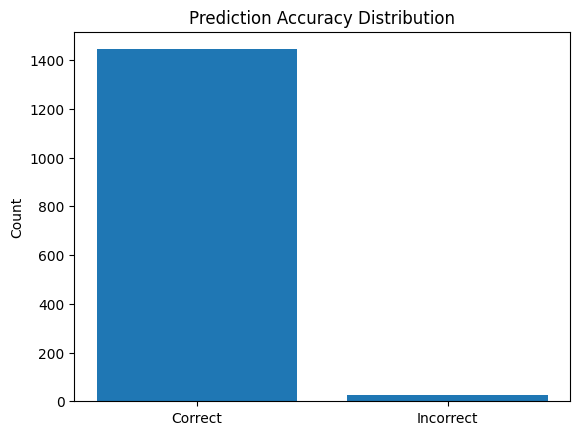

In [4]:
correct = (y_test == y_pred).sum()
incorrect = (y_test != y_pred).sum()

plt.figure()
plt.bar(["Correct", "Incorrect"], [correct, incorrect])
plt.title("Prediction Accuracy Distribution")
plt.ylabel("Count")
plt.show()


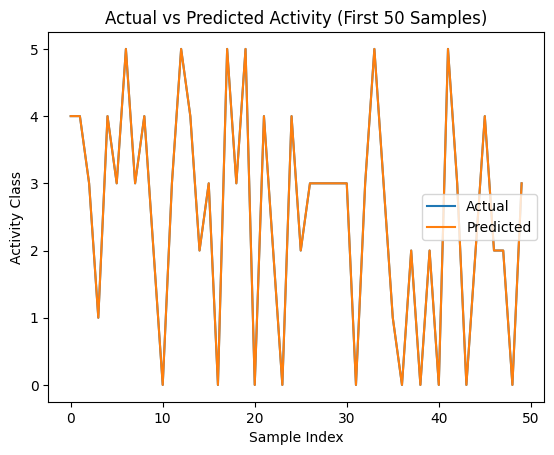

In [5]:
plt.figure()
plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")
plt.title("Actual vs Predicted Activity (First 50 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Activity Class")
plt.legend()
plt.show()


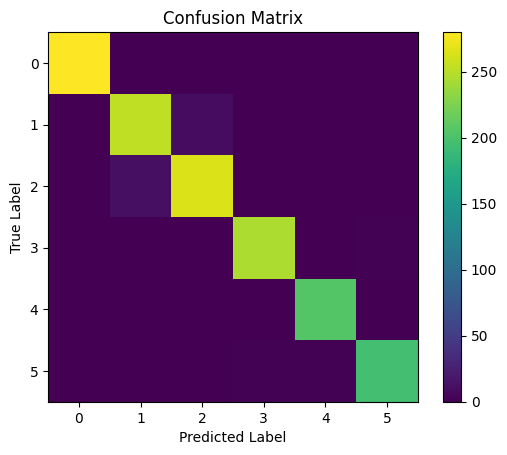

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()


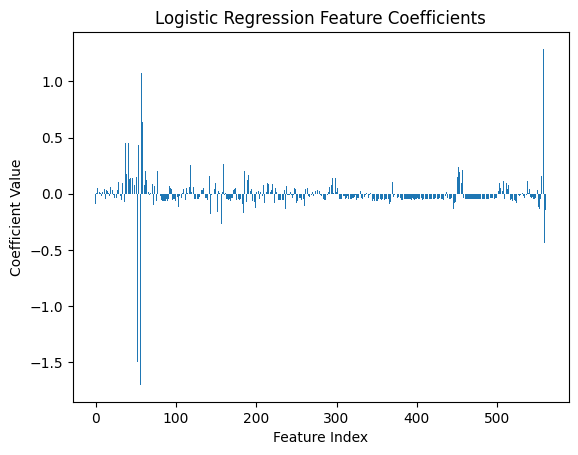

In [7]:
plt.figure()
plt.bar(range(len(model.coef_[0])), model.coef_[0])
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.show()


In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [10]:
pca_model = LogisticRegression(max_iter=1000)
pca_model.fit(X_train_pca, y_train)

y_pred_pca = pca_model.predict(X_test_pca)


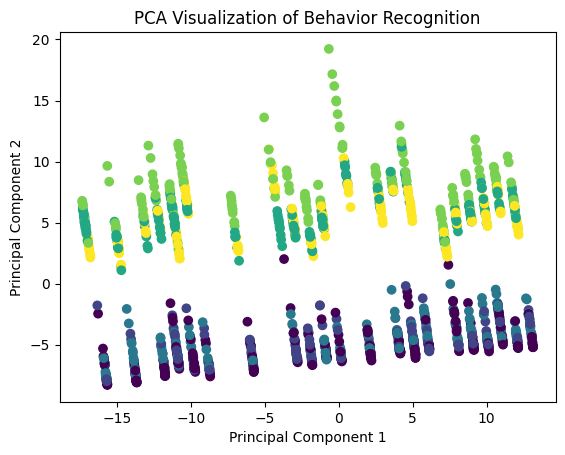

In [11]:

plt.figure()
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Behavior Recognition")
plt.show()
